## Variance-based Sensitivity Analysis [Sobol' Method] 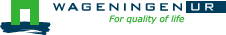


Global sensitivity analysis as per Dr. Ilya Meyerovich Sobol' method [see Notebook 10 (de Wit, 2022)]

In this notebook, the sensitivity of different important scalar parameters will be analysed. Hereby, you can know which one is more important to be accurate for. This analysis offers more insight as to why the initialized WOFOST model performs poorly, as to be explained of the many assumptions made regarding crop parameters being derived from similar C4-crops close to Miscanthus, mainly sugarcane.

Hereby, this study allows where future research and data should be focussed to improve the model.

%pip install SALib tqdm progressbar

%pip install joblib

In [80]:
import sys, os.path
import yaml
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from SALib.sample import saltelli
from SALib.analyze import sobol
import matplotlib.pyplot as plt
from IPython.display import display
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 250)

from functools import partial, lru_cache
from collections import namedtuple
import multiprocessing as mp

import pcse
from pcse.models import Wofost72_PP, Wofost72_WLP_CWB
from pcse.base import ParameterProvider
from pcse.input import YAMLCropDataProvider, CABOFileReader, WOFOST72SiteDataProvider, ExcelWeatherDataProvider, YAMLAgroManagementReader
#from progressbar import printProgressBar

print("This notebook was built with:")
print(f"python version: {sys.version}")
print(f"PCSE version: {pcse.__version__}")

This notebook was built with:
python version: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:07:20) [Clang 20.1.8 ]
PCSE version: 6.0.12


TSUM1, TSUM2, RGRLAI, Q10, SPAN ---- OR Sensitivity Analysis for Scalar Parameters relevant to different Marginal Conditions ??

## Model Initialization

In [ ]:
# Project root
project = Path("/Users/paulianoprescu/Projects/wofost_miscanthus/sinensis/miscanthus_calibration")
input_dir = project / "input_params"

crop_file    = input_dir / "miscanthus" / "miscanthus.yaml"
soil_file    = input_dir / "soil" / "soil_10110.soil"    
weather_file = input_dir / "weather" / "veenkampen_weather.xlsx"

# Load files
cropdata = YAMLCropDataProvider(fpath=crop_file.parent, force_reload=True)
cropdata.set_active_crop("miscanthus", "miscanthus_sinensis")
soildata = CABOFileReader(soil_file)

# Site Conditions
# Compute WAV as 50% between field capacity and wilting point
SMFCF = soildata["SMFCF"]
SMW   = soildata["SMW"]
RDI   = cropdata["RDI"]        # initial rooting depth (cm)
wav_init = 0.5 * (SMFCF - SMW) * RDI * 10   # mm
print(f"Initial WAV = {wav_init:.1f} mm  (50% between FC and WP)")
sitedata = WOFOST72SiteDataProvider(WAV=wav_init)

params = ParameterProvider(cropdata=cropdata, soildata=soildata, sitedata=sitedata)
weather = ExcelWeatherDataProvider(weather_file)

# Create season specific crop calendar you want to simulate [2016: Potential Production Analysis; 2017: Water Limited Production Analysis]
agro_yaml = """
- 2017-10-01:
    CropCalendar:
        crop_name: miscanthus
        variety_name: miscanthus_sinensis
        crop_start_date: 2018-01-01
        crop_start_type: emergence
        crop_end_date: 2018-12-30
        crop_end_type: harvest
        max_duration: 300
    TimedEvents: null
    StateEvents: null
"""
agromanagement = yaml.safe_load(agro_yaml)

Initial WAV = 11.9 mm  (50% between FC and WP)


## Defining Analysis

In [82]:
# Target variable 
target_variable = "TAGP"

# For each scalar parameter, determine a sensible interval
problem_yaml = """
    num_vars: 7
    names:
    - TSUM1
    - TSUM2
    - RGRLAI
    - Q10
    - TDWI
    - RDI
    - RDMCR
    bounds:
    - [1500, 2000]
    - [100, 500]
    - [0.01, 0.1]
    - [1.8, 2.2]
    - [400, 800]
    - [5, 100]
    - [150, 250]
"""
problem = yaml.safe_load(problem_yaml)

# First & Second Order Sensivities using Saltelli Sampler
calc_second_order = True
nsamples = 1024
paramsets = saltelli.sample(problem, nsamples, calc_second_order=calc_second_order)
print("We are going to do %s simulations" % len(paramsets))

print("TSUM1" in params, "→", params["TSUM1"])
for name in problem["names"]:
    print(name, "→", "OK" if name in params else "MISSING")

We are going to do 16384 simulations
True → 1796.93
TSUM1 → OK
TSUM2 → OK
RGRLAI → OK
Q10 → OK
TDWI → OK
RDI → OK
RDMCR → OK


/var/folders/07/x3tw6f7d02b9sg78zrz3df7r0000gn/T/ipykernel_66191/2217099938.py:29: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  paramsets = saltelli.sample(problem, nsamples, calc_second_order=calc_second_order)


## Multiprocessing Saltelli Sample Runs

In [83]:
def run_wofost_simulation(paramset, problem, target_variable):
    params.clear_override()
    for name, value in zip(problem["names"], paramset):
        params.set_override(name, value)

    wofost = Wofost72_WLP_CWB(params, weather, agromanagement)
    wofost.run_till_terminate()
    r = wofost.get_summary_output()
    target_result = r[0][target_variable]
    if target_result is None:
        print("Target variable is not available in summary output!")
    return target_result


run_wofost_partial = partial(run_wofost_simulation,
                             target_variable=target_variable,
                             problem=problem)

from joblib import Parallel, delayed

target_results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
    delayed(run_wofost_partial)(paramset) for paramset in paramsets
)
target_results = np.array(target_results)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   

KeyboardInterrupt: 

In [ ]:
np.save("sa_target_results_N1024.npy", target_results)
np.save("sa_paramsets_N1024.npy", paramsets)

## Computing Sobol Sensitivity Indices

In [ ]:
# Use the Sobol method to analyse the results of the simulations
Si = sobol.analyze(problem, target_results, calc_second_order=calc_second_order)

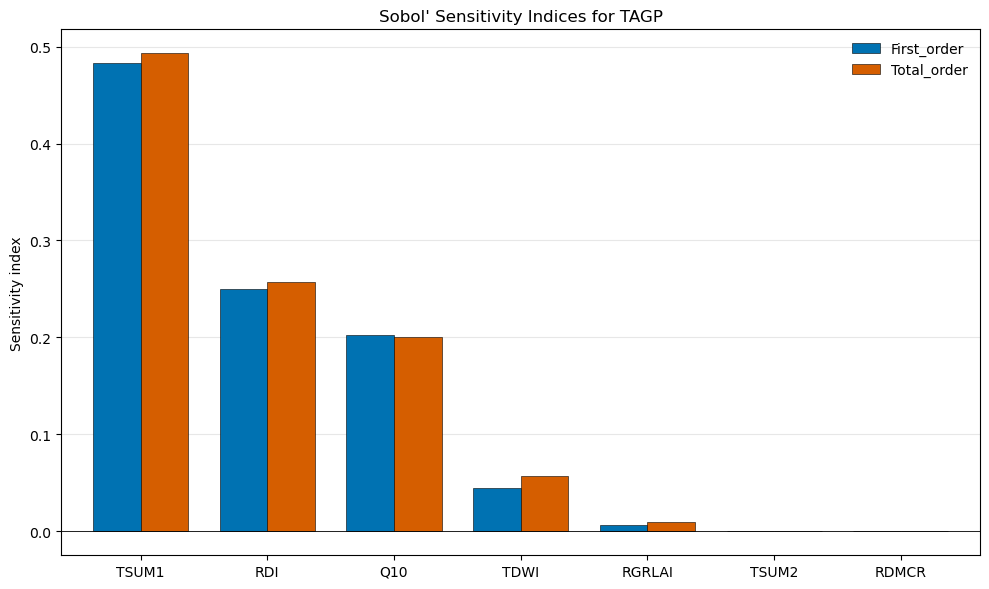

In [ ]:
# Plot
df_sensitivity = pd.DataFrame({
    "Parameter": problem["names"],
    "First_order": Si["S1"],
    "Total_order": Si["ST"]}).set_index("Parameter")

# First-order and Total-order Sobol indices
first = "#0072B2"   
total = "#D55E00"

# Sort by total-order so most influential parameter is leftmost
df_sensitivity = df_sensitivity.sort_values("Total_order", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
df_sensitivity.plot(kind="bar", ax=ax, color=[first, total],
                    edgecolor="black", linewidth=0.4, width=0.75)
ax.set_title(f"Sobol' Sensitivity Indices for {target_variable}")
ax.set_ylabel("Sensitivity index")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.axhline(0, color="black", linewidth=0.6)
ax.legend(frameon=False)
ax.grid(True, alpha=0.3, axis="y")
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

,TSUM1,TSUM2,RGRLAI,Q10,TDWI,RDI,RDMCR
TSUM1,NaN,-0.000573,0.002411,-0.003355,0.007401,0.004439,-0.000953
TSUM2,NaN,NaN,0.000423,0.000363,0.000255,0.000330,0.000303
RGRLAI,NaN,NaN,NaN,0.001421,0.002551,0.002101,0.002062
Q10,NaN,NaN,NaN,NaN,-0.002468,-0.001347,-0.001680
TDWI,NaN,NaN,NaN,NaN,NaN,0.003156,-0.000855
RDI,NaN,NaN,NaN,NaN,NaN,NaN,0.007001
RDMCR,NaN,NaN,NaN,NaN,NaN,NaN,NaN


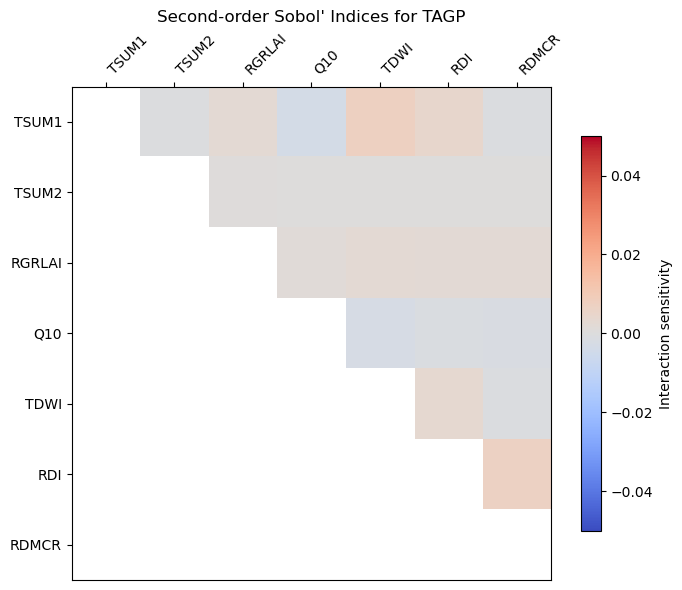

In [ ]:
# Second-order Sobol indices (interaction effects)
second_order = np.array(Si["S2"])

display(pd.DataFrame(second_order,
                     index=problem["names"],
                     columns=problem["names"]))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(second_order, vmin=-0.05, vmax=0.05, cmap="coolwarm", aspect="auto")

ax.set_xticks(range(len(problem["names"])))
ax.set_yticks(range(len(problem["names"])))

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.set_xticklabels(problem["names"], rotation=45, ha="left")
ax.set_yticklabels(problem["names"])
ax.set_title(f"Second-order Sobol' Indices for {target_variable}")

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Interaction sensitivity")

fig.tight_layout()
plt.show()

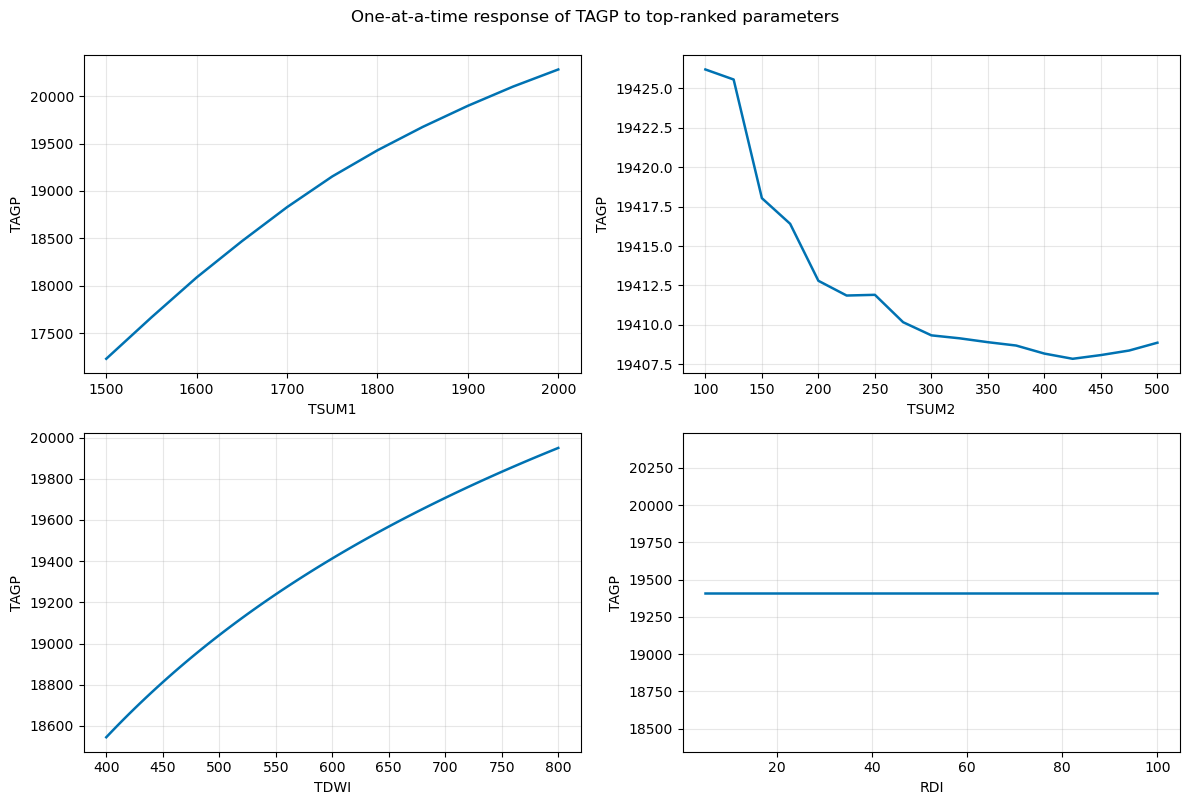

In [ ]:
params_to_sweep = {
    "TSUM1":  list(range(1500, 2001, 50)),
    "TSUM2":  list(range(100, 501, 25)),
    "TDWI":   list(range(400, 801, 5)),
    "RDI":    list(range(5, 101, 5)),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (pname, values) in zip(axes.flatten(), params_to_sweep.items()):
    results = []
    for v in values:
        params.clear_override()
        params.set_override(pname, v)
        wofost = Wofost72_PP(params, weather, agromanagement)
        wofost.run_till_terminate()
        r = wofost.get_summary_output()
        results.append(r[0][target_variable])
    ax.plot(values, results, color="#0072B2", linewidth=1.8)
    ax.set_xlabel(pname)
    ax.set_ylabel(target_variable)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"One-at-a-time response of {target_variable} to top-ranked parameters", y=1.0)
fig.tight_layout()
plt.show()